<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/15_Mini_project/Analyzing_Crime_in_Los_Angeles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Project Description
Los Angeles, California, attracts people from all over the world, offering lots of opportunities, not always of the good kind!

In this project, you'll serve as a data detective, supporting the Los Angeles Police Department (LAPD) in analyzing crime data to guide how they should allocate resources to protect the people of their city!
```



### Explore the crimes.csv dataset and use your findings to answer the following questions:

- Which hour has the highest frequency of crimes? Store as an integer variable called peak_crime_hour.
- Which area has the largest frequency of night crimes (crimes committed between 10pm and 3:59am)? Save as a string variable called peak_night_crime_location.
- Identify the number of crimes committed against victims of different age groups. Save as a pandas Series called victim_ages, with age group labels "0-17", "18-25", "26-34", "35-44", "45-54", "55-64", and "65+" as the index and the frequency of crimes as the values.

In [6]:
import pandas as pd

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/15_Mini_project/Dataset/crimes.csv"

# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv(url, dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085.0,22-07-2022,12-05-2020,1110,Southwest,THEFT OF IDENTITY,27.0,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040.0,06-08-2022,04-06-2020,1620,Olympic,THEFT OF IDENTITY,60.0,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831.0,18-08-2022,17-08-2020,1200,Hollywood,THEFT OF IDENTITY,28.0,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725.0,27-02-2023,27-01-2020,635,77th Street,THEFT OF IDENTITY,37.0,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256.0,14-07-2022,14-07-2020,900,Rampart,THEFT OF IDENTITY,79.0,M,B,NaN,Invest Cont,1200 W 7TH ST


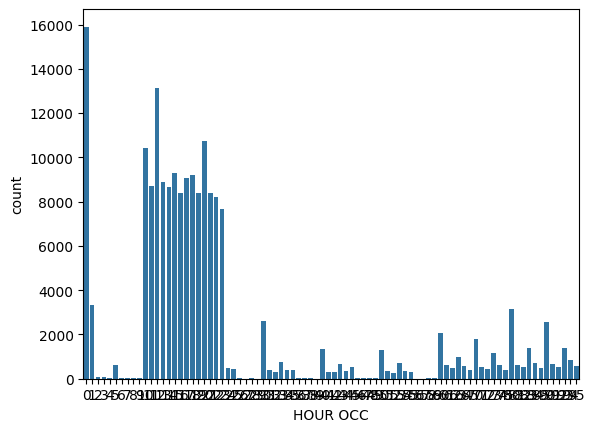

The area with the largest volume of night crime is Central
Age Bracket
26-34    43388
35-44    38562
45-54    25942
18-25    25906
55-64    18457
65+      13468
0-17      4091
Name: count, dtype: int64


In [25]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read in and preview the dataset
crimes = pd.read_csv(url, dtype={"TIME OCC": str})
crimes.head()

## Which hour has the highest frequency of crimes? Store as an integer variable called peak_crime_hour

# Extract the first two digits from "TIME OCC", representing the hour,
# and convert to integer data type
crimes["TIME OCC"] = crimes["TIME OCC"].fillna("0000")
crimes["HOUR OCC"] = crimes["TIME OCC"].str[:2].astype(int)

# Preview the DataFrame to confirm the new column is correct
crimes.head()

# Produce a countplot to find the largest frequency of crimes by hour
sns.countplot(data=crimes, x="HOUR OCC")
plt.show()

# Midday has the largest volume of crime
peak_crime_hour = 12

## Which area has the largest frequency of night crimes (crimes committed between 10pm and 3:59am)?
## Save as a string variable called peak_night_crime_location
# Filter for the night-time hours
# 0 = midnight; 3 = crimes between 3am and 3:59am, i.e., don't include 4
night_time = crimes[crimes["HOUR OCC"].isin([22,23,0,1,2,3])]

# Group by "AREA NAME" and count occurrences, filtering for the largest value and saving the "AREA NAME"
peak_night_crime_location = night_time.groupby("AREA NAME",
                                               as_index=False)["HOUR OCC"].count().sort_values("HOUR OCC",
                                                                                               ascending=False).iloc[0]["AREA NAME"]
# Print the peak night crime location
print(f"The area with the largest volume of night crime is {peak_night_crime_location}")

## Identify the number of crimes committed against victims by age group (0-17, 18-25, 26-34, 35-44, 45-54, 55-64, 65+)
## Save as a pandas Series called victim_ages
# Create bins and labels for victim age ranges
age_bins = [0, 17, 25, 34, 44, 54, 64, np.inf]
age_labels = ["0-17", "18-25", "26-34", "35-44", "45-54", "55-64", "65+"]

# Add a new column using pd.cut() to bin values into discrete intervals
crimes["Age Bracket"] = pd.cut(crimes["Vict Age"],
                               bins=age_bins,
                               labels=age_labels)

# Find the category with the largest frequency
victim_ages = crimes["Age Bracket"].value_counts()
print(victim_ages)